In [1]:
# Imports
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Save folder
save_dir = r"C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1"
save_directory = save_dir
os.makedirs(save_dir, exist_ok=True)


## Problem 0

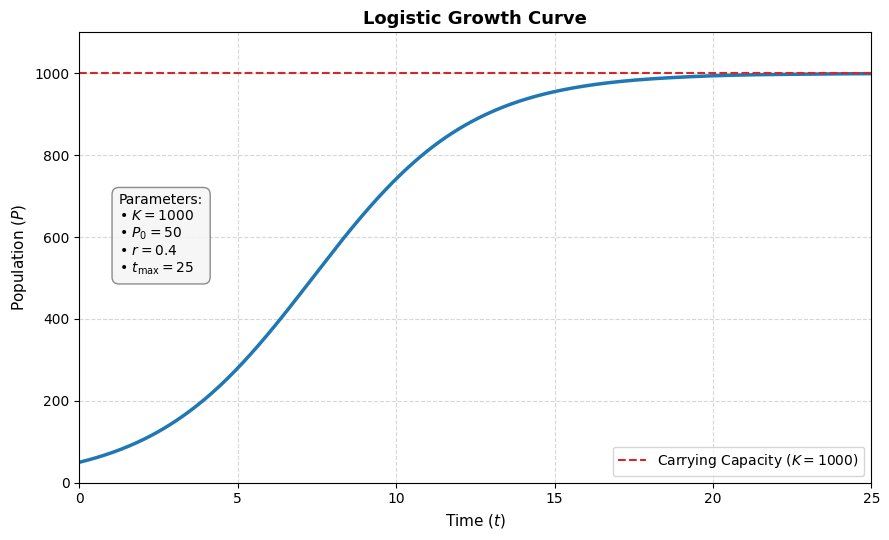

In [2]:
# Parameters
K = 1000.0
P0 = 50.0
r = 0.4
t_max = 25

# Differential equation
def logistic_ode(t, P, r, K):
    return r * P * (1.0 - P / K)

# Solve
t_eval = np.linspace(0, t_max, 500)

sol = solve_ivp(
    fun=logistic_ode,
    t_span=(0, t_max),
    y0=[P0],
    args=(r, K),
    t_eval=t_eval,
    method="RK45"
)

t = sol.t
P = sol.y[0]

# Plot
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(t, P, color="tab:blue", linewidth=2.5)

ax.axhline(K, color="tab:red", linestyle="--", linewidth=1.5, label=f"Carrying Capacity ($K = {K:.0f}$)")

param_text = (
    f"Parameters:\n"
    f"• $K = {K:.0f}$\n"
    f"• $P_0 = {P0:.0f}$\n"
    f"• $r = {r}$\n"
    f"• $t_{{\\max}} = {t_max}$"
)
ax.text(
    0.05, 0.55, param_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="whitesmoke", edgecolor="gray", alpha=0.9)
)

ax.set_title("Logistic Growth Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Time ($t$)", fontsize=11)
ax.set_ylabel("Population ($P$)", fontsize=11)
ax.set_xlim(0, t_max)
ax.set_ylim(0, K * 1.1)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()

# Save and display
save_path = os.path.join(save_dir, "logistic de.png")

plt.savefig(save_path, dpi=300)
plt.show()


## Problem 1

--- Computational Iteration (Iterated to Numerical Convergence) ---
x0 = 0.1  | Steps to converge: 18 | First steps: ['0.1000', '0.3162', '0.5623', '0.7499', '0.8660', '0.9306'] ... -> Converges to: 0.99999
x0 = 0.5  | Steps to converge: 17 | First steps: ['0.5000', '0.7071', '0.8409', '0.9170', '0.9576', '0.9786'] ... -> Converges to: 0.99999
x0 = 3.5  | Steps to converge: 17 | First steps: ['3.5000', '1.8708', '1.3678', '1.1695', '1.0814', '1.0399'] ... -> Converges to: 1.00001

Cobweb plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P1 Map.png
Time series plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P1 Time Series.png


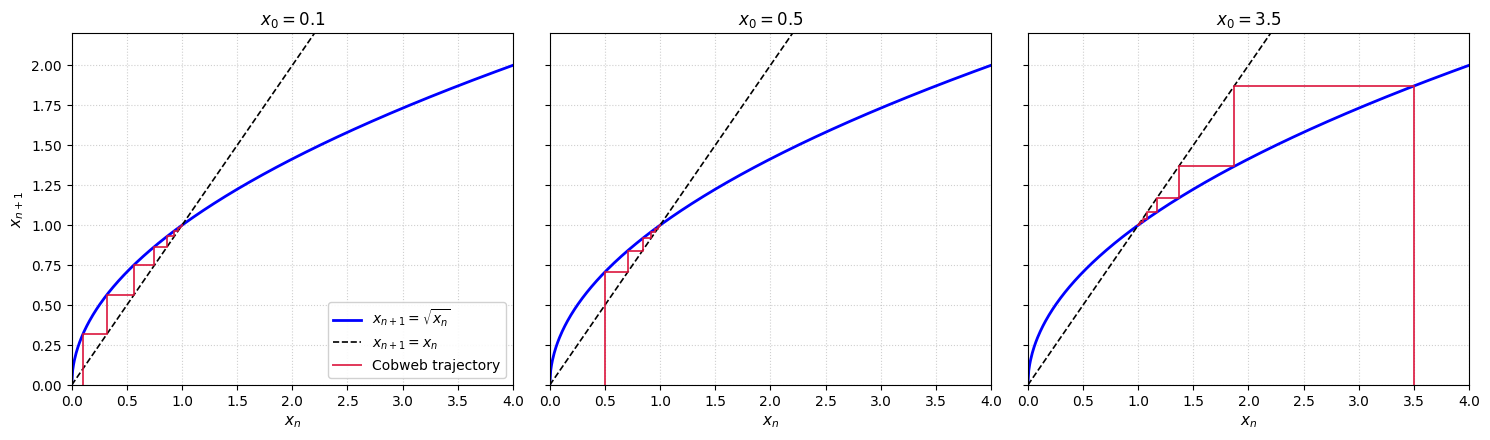

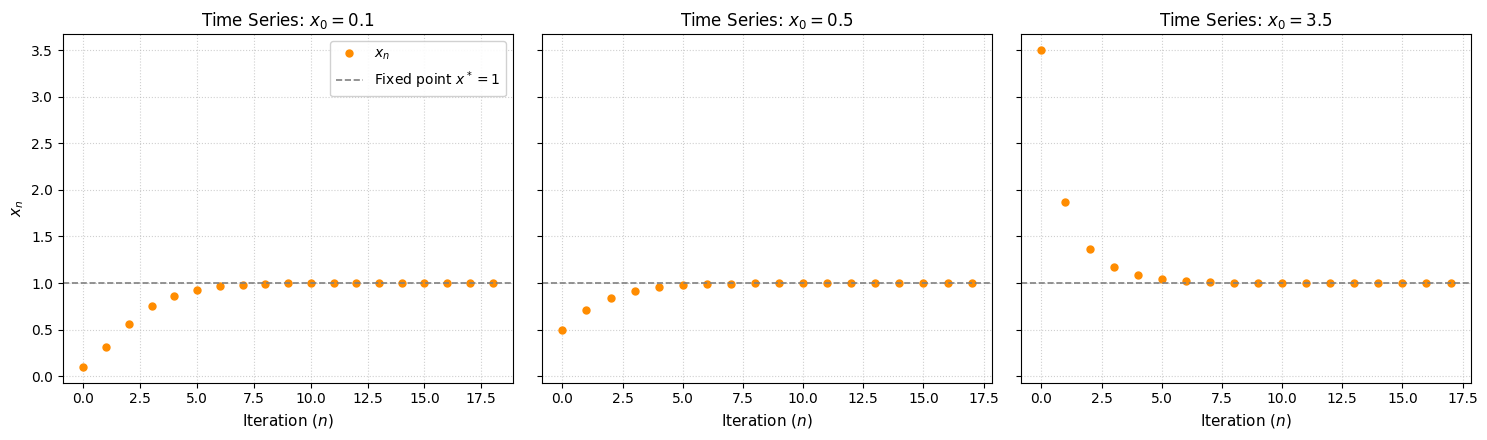

In [3]:
# Map and iteration
def f(x):
    return math.sqrt(x)

def iterate_until_convergence(x0, tol=1e-5, max_steps=100):
    orbit = [x0]
    for i in range(max_steps):
        orbit.append(f(orbit[-1]))
        if abs(orbit[-1] - orbit[-2]) < tol:
            break
    return orbit

# Parameters
test_x0s = [0.1, 0.5, 3.5]
tolerance = 1e-5
max_iter = 60

print("--- Computational Iteration (Iterated to Numerical Convergence) ---")

# Iterations
orbits = {}
for x0 in test_x0s:
    orbit = iterate_until_convergence(x0, tol=tolerance, max_steps=max_iter)
    orbits[x0] = orbit
    first_few = [f"{val:.4f}" for val in orbit[:6]]
    last_val = f"{orbit[-1]:.5f}"
    print(
        f"x0 = {x0:<4} | Steps to converge: {len(orbit)-1:<2} | First steps: {first_few} ... -> Converges to: {last_val}"
    )

# Cobweb plots
fig_cobweb, axes = plt.subplots(
    1, len(test_x0s), figsize=(5 * len(test_x0s), 4.5), sharey=True
)

for ax, x0 in zip(axes, test_x0s):
    x_max = max(4.0, x0 + 0.5)

    x_vals = np.linspace(0, x_max, 500)
    fx_vals = [math.sqrt(val) for val in x_vals]

    ax.plot(
        x_vals, fx_vals, "b-", linewidth=2, label=r"$x_{n+1} = \sqrt{x_n}$"
    )
    ax.plot(x_vals, x_vals, "k--", linewidth=1.2, label=r"$x_{n+1} = x_n$")

    orbit = orbits[x0]
    cx = [orbit[0], orbit[0]]
    cy = [0.0, orbit[1]]

    for i in range(1, len(orbit) - 1):
        curr_x = orbit[i]
        next_x = orbit[i + 1]
        cx.append(curr_x)
        cy.append(curr_x)
        cx.append(curr_x)
        cy.append(next_x)

    ax.plot(
        cx,
        cy,
        color="crimson",
        linewidth=1.4,
        alpha=0.85,
        label="Cobweb trajectory",
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, math.sqrt(x_max) + 0.2)
    ax.set_xlabel(r"$x_n$", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel(r"$x_{n+1}$", fontsize=11)
        ax.legend(loc="lower right", framealpha=0.9)
    ax.set_title(f"$x_0 = {x0}$", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

fig_cobweb.tight_layout()

# Time series
fig_ts, axes_ts = plt.subplots(
    1, len(test_x0s), figsize=(5 * len(test_x0s), 4.5), sharey=True
)

for ax, x0 in zip(axes_ts, test_x0s):
    orbit = orbits[x0]
    n_vals = list(range(len(orbit)))

    ax.plot(n_vals, orbit, "o", color="darkorange", markersize=5, label=r"$x_n$")

    ax.axhline(
        1.0,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label=r"Fixed point $x^* = 1$",
    )

    ax.set_xlabel(r"Iteration ($n$)", fontsize=11)
    if ax is axes_ts[0]:
        ax.set_ylabel(r"$x_n$", fontsize=11)
        ax.legend(loc="upper right", framealpha=0.9)
    ax.set_title(f"Time Series: $x_0 = {x0}$", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

fig_ts.tight_layout()

# Save and display
cobweb_save_path = os.path.join(save_directory, "P1 Map.png")
ts_save_path = os.path.join(save_directory, "P1 Time Series.png")

fig_cobweb.savefig(cobweb_save_path, dpi=300, bbox_inches="tight")
fig_ts.savefig(ts_save_path, dpi=300, bbox_inches="tight")

print(f"\nCobweb plot saved to: {cobweb_save_path}")
print(f"Time series plot saved to: {ts_save_path}")

plt.show()


## Problem 2


x0 = 0.45
n =  0: x_n = 0.45
n =  1: x_n = 0.4830550656165784
n =  2: x_n = 0.5245001395318706
n =  3: x_n = 0.5785527138488251
n =  4: x_n = 0.6531018793704128
n =  5: x_n = 0.7651104724322025
n =  6: x_n = 0.9602260820218552
n =  7: x_n = 1.429045048686377
n =  8: x_n = 7.007296270206815
n =  9: x_n = 0.8843675741853587
n = 10: x_n = 1.220479923005943
n = 11: x_n = 2.73682349841732
n = 12: x_n = -0.4284262810045865
n = 13: x_n = -0.4567176712253356
n = 14: x_n = -0.491367351447327
n = 15: x_n = -0.5351457965576384
n = 16: x_n = -0.5928503198449545
n = 17: x_n = -0.6736916820920491
n = 18: x_n = -0.7982806559846675
n = 19: x_n = -1.026102696979913
n = 20: x_n = -1.650634066442698
n = 21: x_n = 12.49878081180137
n = 22: x_n = -0.06769291631959969
n = 23: x_n = -0.06779650330618626
n = 24: x_n = -0.06790056714765705
n = 25: x_n = -0.06800511151320529
n = 26: x_n = -0.06811014011166708
n = 27: x_n = -0.06821565669207358
n = 28: x_n = -0.06832166504421285
n = 29: x_n = -0.068428168999201

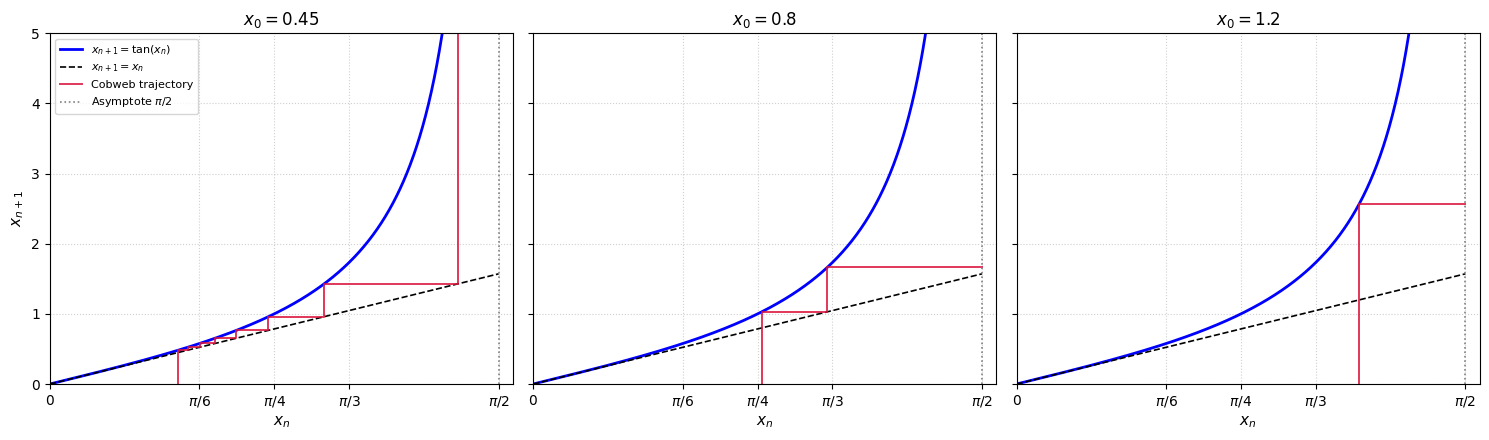

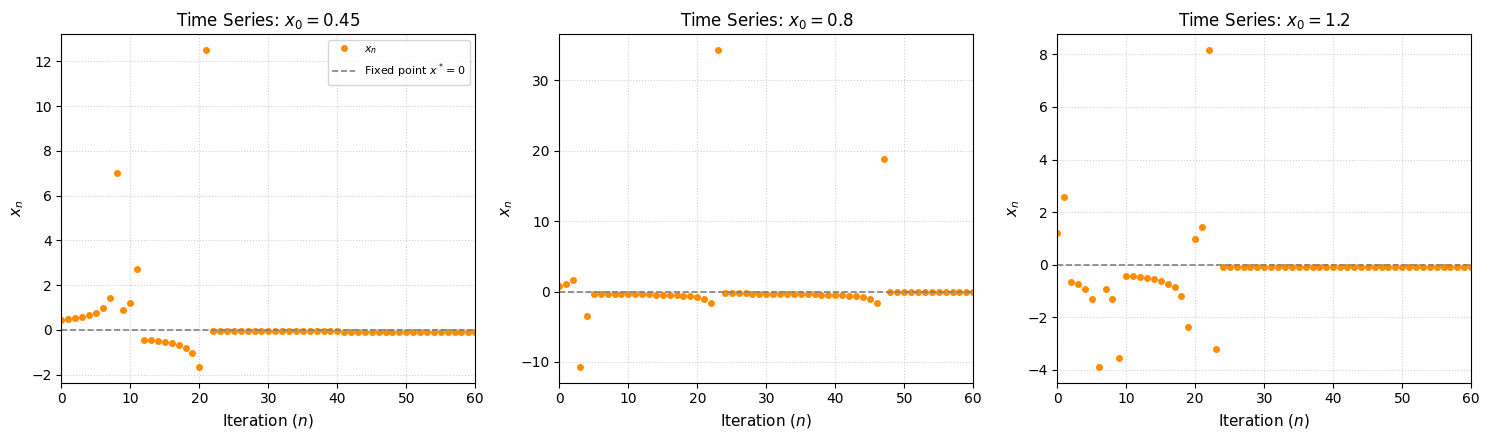

In [4]:
# Parameters
test_x0s = [0.45, 0.8, 1.2]
total_steps = 60

# Map
def tan_step(x):
    return math.tan(x)

# Iterations
orbits = {}

for x0 in test_x0s:
    orbit = [x0]

    for _ in range(total_steps):
        orbit.append(tan_step(orbit[-1]))

    orbits[x0] = np.array(orbit)

# Cobweb plots
x_max = math.pi / 2
y_max = 5.0

fig_cobweb, axes = plt.subplots(
    1, len(test_x0s),
    figsize=(15, 4.5),
    sharey=True,
    squeeze=False,
)
axes = axes.ravel()

x_curve = np.linspace(0, math.atan(y_max), 800)

for ax, x0 in zip(axes, test_x0s):
    ax.plot(
        x_curve, np.tan(x_curve),
        color="blue", lw=2,
        label=r"$x_{n+1}=\tan(x_n)$",
    )
    ax.plot(
        [0, x_max], [0, x_max],
        "k--", lw=1.2,
        label=r"$x_{n+1}=x_n$",
    )

    cx = [x0]
    cy = [0.0]

    for curr_x, next_x in zip(orbits[x0][:-1], orbits[x0][1:]):
        cx.append(curr_x)
        cy.append(min(next_x, y_max))

        if next_x >= y_max:
            break

        cx.append(min(next_x, x_max))
        cy.append(next_x)

        if next_x >= x_max:
            break

    ax.plot(
        cx, cy,
        color="crimson", lw=1.4, alpha=0.85,
        label="Cobweb trajectory",
    )
    ax.axvline(
        x_max,
        color="gray", ls=":", lw=1.2,
        label=r"Asymptote $\pi/2$",
    )

    ax.set_xlim(0, x_max + 0.05)
    ax.set_ylim(0, y_max)
    ax.set_xticks([
        0,
        math.pi / 6,
        math.pi / 4,
        math.pi / 3,
        math.pi / 2,
    ])
    ax.set_xticklabels([
        r"$0$",
        r"$\pi/6$",
        r"$\pi/4$",
        r"$\pi/3$",
        r"$\pi/2$",
    ])
    ax.set_xlabel(r"$x_n$", fontsize=11)
    ax.set_title(rf"$x_0={x0}$")
    ax.grid(True, ls=":", alpha=0.6)

axes[0].set_ylabel(r"$x_{n+1}$", fontsize=11)
axes[0].legend(loc="upper left", fontsize=8)

fig_cobweb.tight_layout()

# Time series
fig_ts, axes_ts = plt.subplots(
    1, len(test_x0s),
    figsize=(15, 4.5),
    squeeze=False,
)
axes_ts = axes_ts.ravel()

for ax, x0 in zip(axes_ts, test_x0s):
    vals = orbits[x0]
    n_vals = np.arange(len(vals))

    ax.plot(
        n_vals, vals,
        "o", color="darkorange", ms=4, lw=0.8,
        label=r"$x_n$",
    )
    ax.axhline(
        0,
        color="gray", ls="--", lw=1.2,
        label=r"Fixed point $x^*=0$",
    )

    ax.set_xlim(0, total_steps)
    ax.set_xlabel(r"Iteration ($n$)", fontsize=11)
    ax.set_ylabel(r"$x_n$", fontsize=11)
    ax.set_title(rf"Time Series: $x_0={x0}$")
    ax.grid(True, ls=":", alpha=0.6)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes_ts[0].legend(loc="best", fontsize=8)

fig_ts.tight_layout()

# Print values
for x0, orbit in orbits.items():
    print(f"\nx0 = {x0}")
    for n, x in enumerate(orbit):
        print(f"n = {n:2d}: x_n = {x:.16g}")

# Save and display
cobweb_path = os.path.join(save_directory, "P2 Map.png")
ts_path = os.path.join(save_directory, "P2 Time Series.png")

fig_cobweb.savefig(cobweb_path, dpi=300, bbox_inches="tight")
fig_ts.savefig(ts_path, dpi=300, bbox_inches="tight")

print(f"\nCobweb plot saved to: {cobweb_path}")
print(f"Time series plot saved to: {ts_path}")

plt.show()


## Problem 3

Map plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\Sine_Map.png


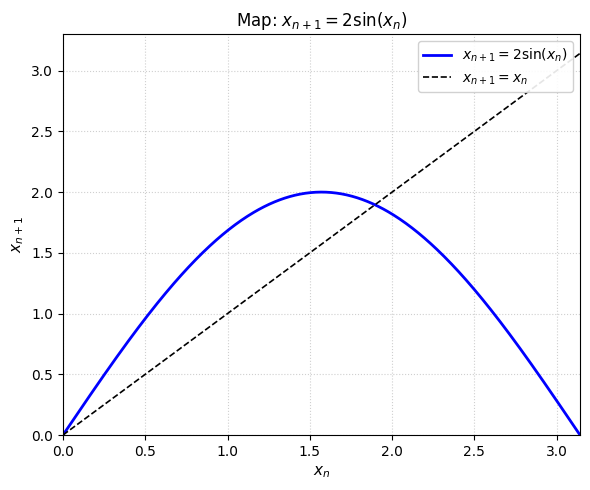

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np

# Map parameter
a = 2

# Domain setup
x_max = np.pi
x_vals = np.linspace(0, x_max, 500)
fx_vals = a * np.sin(x_vals)

# --- Plot Map and Diagonal ---
fig, ax = plt.subplots(figsize=(6, 5))

# Reference curves
ax.plot(
    x_vals,
    fx_vals,
    "b-",
    linewidth=2,
    label=rf"$x_{{n+1}} = {a}\sin(x_n)$",
)
ax.plot(x_vals, x_vals, "k--", linewidth=1.2, label=r"$x_{n+1} = x_n$")

ax.set_xlim(0, x_max)
ax.set_ylim(0, max(a, x_max) * 1.05)
ax.set_xlabel(r"$x_n$", fontsize=11)
ax.set_ylabel(r"$x_{n+1}$", fontsize=11)
ax.set_title(rf"Map: $x_{{n+1}} = {a}\sin(x_n)$", fontsize=12)
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.6)

fig.tight_layout()

# --- Save Figure to Disk ---
save_directory = (
    r"C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1"
)
os.makedirs(save_directory, exist_ok=True)

save_path = os.path.join(save_directory, "Sine_Map.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"Map plot saved to: {save_path}")

plt.show()

In [6]:
import numpy as np
from scipy.optimize import fsolve


# -------- Period 1 -> 2 --------

def equations1(values):
    x, a = values

    return [
        a * np.sin(x) - x,
        a * np.cos(x) + 1
    ]


# Find a starting guess automatically
for a in np.arange(1.1, 3.0, 0.01):

    x = 0.5
    for i in range(2000):
        x = a * np.sin(x)

    error, m = equations1([x, a])

    if abs(error) < 1e-8 and 0 < m < 0.2:
        break


# Solve and check
x, a1 = fsolve(equations1, [x, a])

error, m = equations1([x, a1])
valid1 = abs(error) < 1e-8 and abs(m) < 1e-8

if valid1:
    print("a1 =", a1)
else:
    print("Solver did not find a1")


# -------- Period 2 -> 4 --------

def equations2(values):
    p, a = values
    q = a * np.sin(p)

    return [
        a * np.sin(q) - p,
        a**2 * np.cos(p) * np.cos(q) + 1
    ]


# Find a starting guess automatically
for a in np.arange(1.1, 3.0, 0.01):

    p = 0.5
    for i in range(2000):
        p = a * np.sin(p)

    error, m = equations2([p, a])

    if abs(error) < 1e-8 and 0 < m < 0.2:
        break


# Solve and check
p, a2 = fsolve(equations2, [p, a])

error, m = equations2([p, a2])
valid2 = abs(error) < 1e-8 and abs(m) < 1e-8

if valid2:
    print("a2 =", a2)
else:
    print("Solver did not find a2")


# -------- Period 4 -> 8 --------

def equations3(values):
    x1, a = values

    x2 = a * np.sin(x1)
    x3 = a * np.sin(x2)
    x4 = a * np.sin(x3)

    return [
        a * np.sin(x4) - x1,
        a**4 * np.cos(x1) * np.cos(x2)
             * np.cos(x3) * np.cos(x4) + 1
    ]


# Find a starting guess automatically
for a in np.arange(1.1, 3.0, 0.01):

    x1 = 0.5
    for i in range(2000):
        x1 = a * np.sin(x1)

    error, m = equations3([x1, a])

    if abs(error) < 1e-8 and 0 < m < 0.2:
        break


# Solve and check
x1, a3 = fsolve(equations3, [x1, a])

error, m = equations3([x1, a3])
valid3 = abs(error) < 1e-8 and abs(m) < 1e-8

if valid3:
    print("a3 =", a3)
else:
    print("Solver did not find a3")


# -------- Feigenbaum constant estimate --------

if valid1 and valid2 and valid3:
    delta = (a2 - a1) / (a3 - a2)
    print("delta =", delta)
else:
    print("Cannot calculate delta because a solution failed")

a1 = 2.2618263341146543
a2 = 2.6177834554109998
a3 = 2.697399914889866
delta = 4.470898651186977


## Problem 4

Map plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\Epilepsy_Map_C4.png


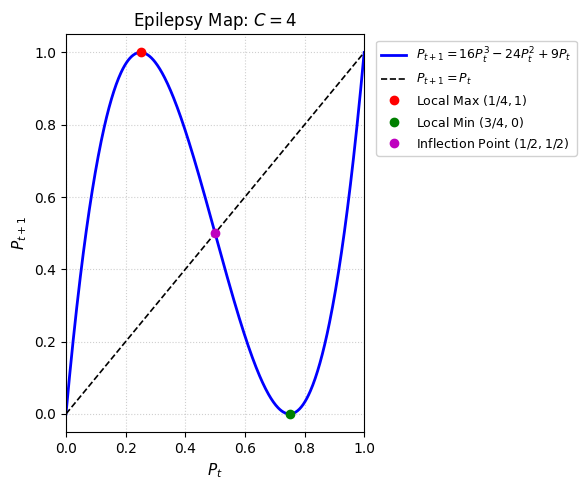

In [7]:
# Parameters
C = 4

# Map
def f(P, C=4):
    return 4 * C * P**3 - 6 * C * P**2 + (1 + 2 * C) * P

# Plot
P_vals = np.linspace(0, 1, 500)
fP_vals = f(P_vals, C=C)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    P_vals,
    fP_vals,
    "b-",
    linewidth=2,
    label=rf"$P_{{t+1}} = 16P_t^3 - 24P_t^2 + 9P_t$",
)
ax.plot(P_vals, P_vals, "k--", linewidth=1.2, label=r"$P_{t+1} = P_t$")

ax.plot(0.25, 1.0, "ro", markersize=6, label=r"Local Max $(1/4, 1)$")
ax.plot(0.75, 0.0, "go", markersize=6, label=r"Local Min $(3/4, 0)$")
ax.plot(0.5, 0.5, "mo", markersize=6, label=r"Inflection Point $(1/2, 1/2)$")

ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"$P_t$", fontsize=11)
ax.set_ylabel(r"$P_{t+1}$", fontsize=11)
ax.set_title(rf"Epilepsy Map: $C = {C}$", fontsize=12)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    framealpha=0.9,
    fontsize=9,
)
ax.grid(True, linestyle=":", alpha=0.6)

fig.tight_layout()

# Save and display
save_path = os.path.join(save_directory, "Epilepsy_Map_C4.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"Map plot saved to: {save_path}")

plt.show()


Initial condition P0 = 0.45
t =  0: P_t = 0.45000000
t =  1: P_t = 0.64800000
t =  2: P_t = 0.10786867
t =  3: P_t = 0.71164439
t =  4: P_t = 0.01675100
t =  5: P_t = 0.14409990
t =  6: P_t = 0.84641960
t =  7: P_t = 0.12590307
t =  8: P_t = 0.78462183
t =  9: P_t = 0.01504806
t = 10: P_t = 0.13005241
t = 11: P_t = 0.79973911
t = 12: P_t = 0.03165660
t = 13: P_t = 0.26136561
t = 14: P_t = 0.99847336

Cobweb plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P4_Cobweb.png
Time series plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P4_Time_Series.png


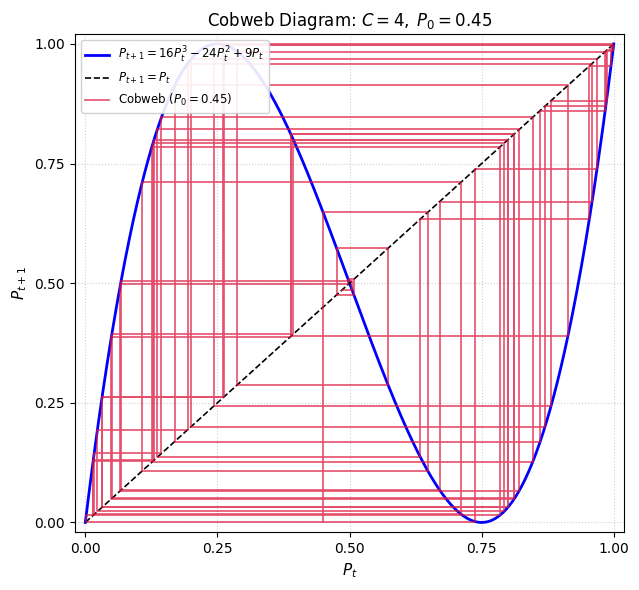

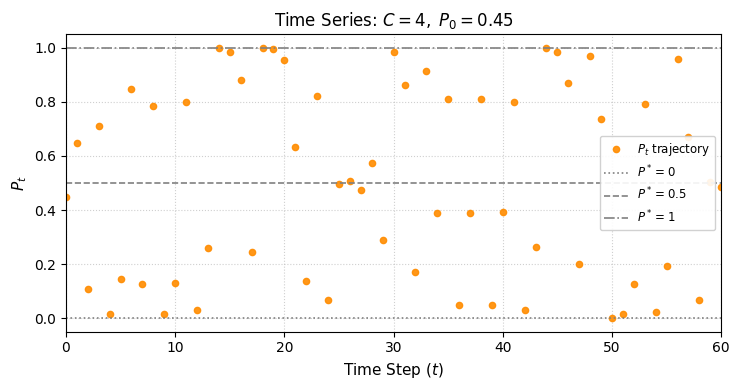

In [8]:
# Parameters
C = 4
P0 = 0.45
total_steps = 60

# Map
def epilepsy_step(P, C=4):
    return 4 * C * P**3 - 6 * C * P**2 + (1 + 2 * C) * P

# Iterations
orbit = [P0]
for _ in range(total_steps):
    orbit.append(epilepsy_step(orbit[-1], C=C))
orbit = np.array(orbit)

# Cobweb plot
fig_cobweb, ax_cobweb = plt.subplots(figsize=(6.5, 6))

P_curve = np.linspace(0, 1, 600)

ax_cobweb.plot(
    P_curve,
    epilepsy_step(P_curve, C=C),
    color="blue",
    lw=2,
    label=rf"$P_{{t+1}} = 16P_t^3 - 24P_t^2 + 9P_t$",
)
ax_cobweb.plot([0, 1], [0, 1], "k--", lw=1.2, label=r"$P_{t+1} = P_t$")

cx = [P0]
cy = [0.0]

for curr_P, next_P in zip(orbit[:-1], orbit[1:]):
    cx.append(curr_P)
    cy.append(next_P)
    cx.append(next_P)
    cy.append(next_P)

ax_cobweb.plot(
    cx,
    cy,
    color="crimson",
    lw=1.2,
    alpha=0.75,
    label=rf"Cobweb ($P_0={P0}$)",
)

ax_cobweb.set_xlim(-0.02, 1.02)
ax_cobweb.set_ylim(-0.02, 1.02)
ax_cobweb.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_cobweb.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_cobweb.set_xlabel(r"$P_t$", fontsize=11)
ax_cobweb.set_ylabel(r"$P_{t+1}$", fontsize=11)
ax_cobweb.set_title(rf"Cobweb Diagram: $C = {C},\; P_0 = {P0}$", fontsize=12)
ax_cobweb.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax_cobweb.grid(True, ls=":", alpha=0.6)

fig_cobweb.tight_layout()

# Time series
fig_ts, ax_ts = plt.subplots(figsize=(7.5, 4))

t_vals = np.arange(len(orbit))

ax_ts.plot(
    t_vals,
    orbit,
    "o",
    color="darkorange",
    ms=4.5,
    alpha=0.9,
    label=rf"$P_t$ trajectory",
)

ax_ts.axhline(0.0, color="gray", ls=":", lw=1.2, label=r"$P^* = 0$")
ax_ts.axhline(0.5, color="gray", ls="--", lw=1.2, label=r"$P^* = 0.5$")
ax_ts.axhline(1.0, color="gray", ls="-.", lw=1.2, label=r"$P^* = 1$")

ax_ts.set_xlim(0, total_steps)
ax_ts.set_ylim(-0.05, 1.05)
ax_ts.set_xlabel(r"Time Step ($t$)", fontsize=11)
ax_ts.set_ylabel(r"$P_t$", fontsize=11)
ax_ts.set_title(rf"Time Series: $C = {C},\; P_0 = {P0}$", fontsize=12)
ax_ts.grid(True, ls=":", alpha=0.6)
ax_ts.legend(loc="center right", fontsize=8.5, framealpha=0.9)

fig_ts.tight_layout()

# Print values
print(f"Initial condition P0 = {P0}")
for n, p in enumerate(orbit[:15]):
    print(f"t = {n:2d}: P_t = {p:.8f}")

# Save and display
cobweb_path = os.path.join(save_directory, "P4_Cobweb.png")
ts_path = os.path.join(save_directory, "P4_Time_Series.png")

fig_cobweb.savefig(cobweb_path, dpi=300, bbox_inches="tight")
fig_ts.savefig(ts_path, dpi=300, bbox_inches="tight")

print(f"\nCobweb plot saved to: {cobweb_path}")
print(f"Time series plot saved to: {ts_path}")

plt.show()


## Problem 5

Map plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\Problem_5_Map.png


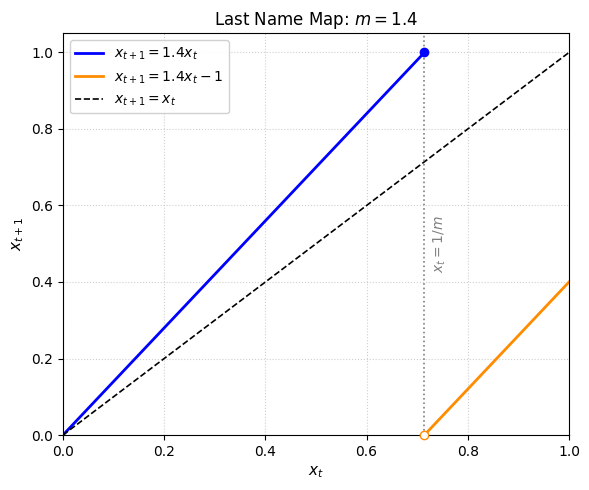

In [9]:
# Parameters
m = 1.4

# Plot
x_max = 1
x_left = np.linspace(0, 1 / m, 500)
x_right = np.linspace(1 / m, x_max, 500)
x_vals = np.linspace(0, x_max, 500)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    x_left,
    m * x_left,
    "b-",
    linewidth=2,
    label=rf"$x_{{t+1}} = {m}x_t$",
)
ax.plot(
    x_right,
    m * x_right - 1,
    color="darkorange",
    linewidth=2,
    label=rf"$x_{{t+1}} = {m}x_t - 1$",
)
ax.plot(
    x_vals,
    x_vals,
    "k--",
    linewidth=1.2,
    label=r"$x_{t+1} = x_t$",
)

ax.plot(1 / m, 1, "bo", markersize=6, zorder=5)
ax.plot(
    1 / m,
    0,
    "o",
    markeredgecolor="darkorange",
    markerfacecolor="white",
    markersize=6,
    zorder=5,
    clip_on=False,
)

ax.axvline(1 / m, color="gray", linestyle=":", linewidth=1.2)
ax.text(
    1 / m + 0.015,
    0.5,
    r"$x_t = 1/m$",
    rotation=90,
    va="center",
    ha="left",
    color="gray",
    fontsize=10,
)

ax.set_xlim(0, x_max)
ax.set_ylim(0, x_max * 1.05)
ax.set_xlabel(r"$x_t$", fontsize=11)
ax.set_ylabel(r"$x_{t+1}$", fontsize=11)
ax.set_title(rf"Last Name Map: $m = {m}$", fontsize=12)
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, linestyle=":", alpha=0.6)

fig.tight_layout()

# Save and display
save_path = os.path.join(save_directory, "Problem_5_Map.png")

fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Map plot saved to: {save_path}")

plt.show()


--- Computational Iteration ---
x0 = 0.1  | Steps: 60 | First steps: ['0.1000', '0.1400', '0.1960', '0.2744', '0.3842', '0.5378'] ... | Final value: 0.50187
x0 = 0.5  | Steps: 60 | First steps: ['0.5000', '0.7000', '0.9800', '0.3720', '0.5208', '0.7291'] ... | Final value: 0.72517
x0 = 0.9  | Steps: 60 | First steps: ['0.9000', '0.2600', '0.3640', '0.5096', '0.7134', '0.9988'] ... | Final value: 0.11730

Cobweb plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P5 Cobweb.png
Time series plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\P5 Time Series.png


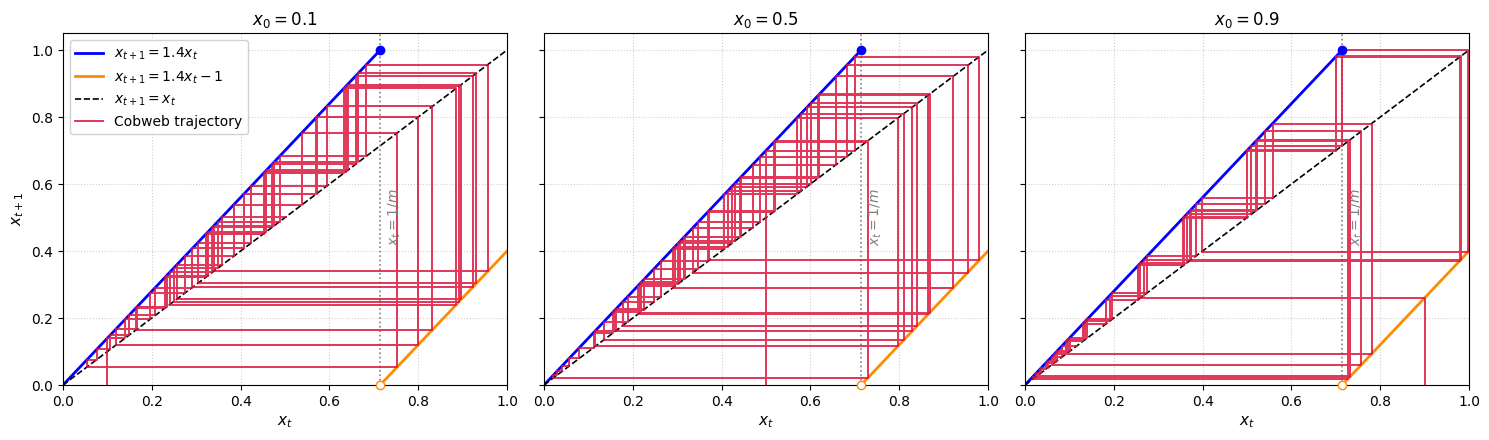

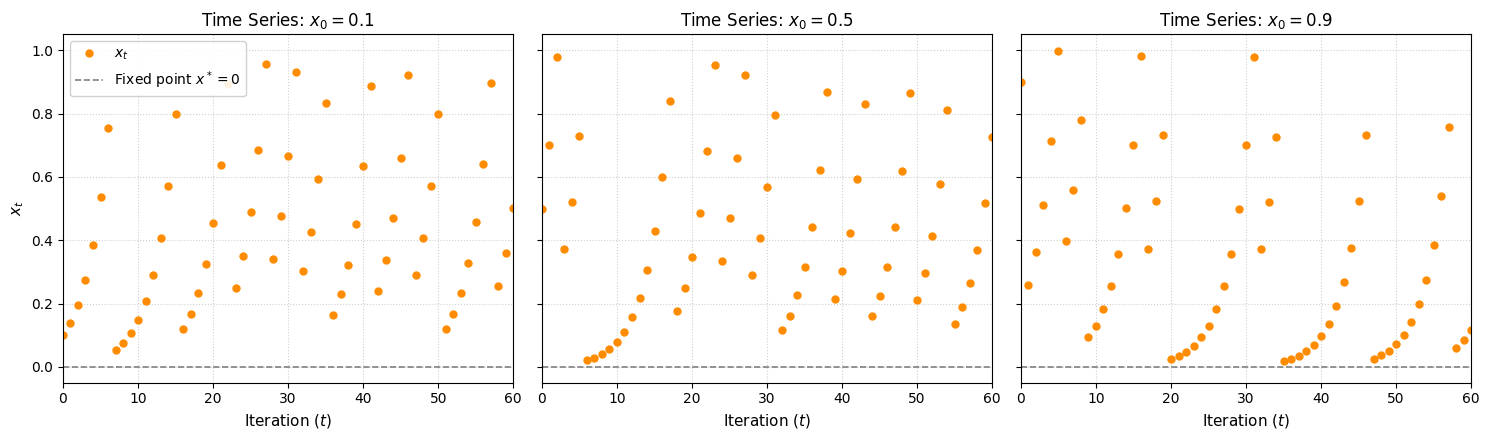

In [10]:
# Parameters
m = 1.4

# Map and iteration
def f(x):
    if x <= 1 / m:
        return m * x
    else:
        return m * x - 1

def iterate(x0, max_steps=60):
    orbit = [x0]

    for i in range(max_steps):
        orbit.append(f(orbit[-1]))

    return orbit

# Initial values
test_x0s = [0.1, 0.5, 0.9]
max_iter = 60

print("--- Computational Iteration ---")

# Iterations
orbits = {}
for x0 in test_x0s:
    orbit = iterate(x0, max_steps=max_iter)
    orbits[x0] = orbit

    first_few = [f"{val:.4f}" for val in orbit[:6]]
    last_val = f"{orbit[-1]:.5f}"

    print(
        f"x0 = {x0:<4} | Steps: {len(orbit)-1:<2} | "
        f"First steps: {first_few} ... | Final value: {last_val}"
    )

# Cobweb plots
fig_cobweb, axes = plt.subplots(
    1, len(test_x0s), figsize=(5 * len(test_x0s), 4.5), sharey=True
)

x_max = 1
x_left = np.linspace(0, 1 / m, 500)
x_right = np.linspace(1 / m, x_max, 500)
x_vals = np.linspace(0, x_max, 500)

for ax, x0 in zip(axes, test_x0s):

    ax.plot(
        x_left,
        m * x_left,
        "b-",
        linewidth=2,
        label=rf"$x_{{t+1}} = {m}x_t$",
    )
    ax.plot(
        x_right,
        m * x_right - 1,
        color="darkorange",
        linewidth=2,
        label=rf"$x_{{t+1}} = {m}x_t - 1$",
    )
    ax.plot(
        x_vals,
        x_vals,
        "k--",
        linewidth=1.2,
        label=r"$x_{t+1} = x_t$",
    )

    ax.plot(1 / m, 1, "bo", markersize=6, zorder=5)
    ax.plot(
        1 / m,
        0,
        "o",
        markeredgecolor="darkorange",
        markerfacecolor="white",
        markersize=6,
        zorder=5,
        clip_on=False,
    )

    ax.axvline(1 / m, color="gray", linestyle=":", linewidth=1.2)
    ax.text(
        1 / m + 0.015,
        0.5,
        r"$x_t = 1/m$",
        rotation=90,
        va="center",
        ha="left",
        color="gray",
        fontsize=10,
    )

    orbit = orbits[x0]
    cx = [orbit[0]]
    cy = [0.0]

    for i in range(len(orbit) - 1):
        curr_x = orbit[i]
        next_x = orbit[i + 1]

        cx.append(curr_x)
        cy.append(next_x)

        cx.append(next_x)
        cy.append(next_x)

    ax.plot(
        cx,
        cy,
        color="crimson",
        linewidth=1.4,
        alpha=0.85,
        label="Cobweb trajectory",
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, x_max * 1.05)
    ax.set_xlabel(r"$x_t$", fontsize=11)

    if ax is axes[0]:
        ax.set_ylabel(r"$x_{t+1}$", fontsize=11)
        ax.legend(loc="upper left", framealpha=0.9)

    ax.set_title(f"$x_0 = {x0}$", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

fig_cobweb.tight_layout()

# Time series
fig_ts, axes_ts = plt.subplots(
    1, len(test_x0s), figsize=(5 * len(test_x0s), 4.5), sharey=True
)

for ax, x0 in zip(axes_ts, test_x0s):
    orbit = orbits[x0]
    t_vals = list(range(len(orbit)))

    ax.plot(
        t_vals,
        orbit,
        "o",
        color="darkorange",
        markersize=5,
        label=r"$x_t$",
    )

    ax.axhline(
        0.0,
        color="gray",
        linestyle="--",
        linewidth=1.2,
        label=r"Fixed point $x^* = 0$",
    )

    ax.set_xlim(0, max_iter)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(r"Iteration ($t$)", fontsize=11)

    if ax is axes_ts[0]:
        ax.set_ylabel(r"$x_t$", fontsize=11)
        ax.legend(loc="upper left", framealpha=0.9)

    ax.set_title(f"Time Series: $x_0 = {x0}$", fontsize=12)
    ax.grid(True, linestyle=":", alpha=0.6)

fig_ts.tight_layout()

# Save and display
cobweb_save_path = os.path.join(save_directory, "P5 Cobweb.png")
ts_save_path = os.path.join(save_directory, "P5 Time Series.png")

fig_cobweb.savefig(cobweb_save_path, dpi=300, bbox_inches="tight")
fig_ts.savefig(ts_save_path, dpi=300, bbox_inches="tight")

print(f"\nCobweb plot saved to: {cobweb_save_path}")
print(f"Time series plot saved to: {ts_save_path}")

plt.show()


## Problem 7

--- Computational Iteration ---
r = 0.8  | x0 = 0.2 | Steps: 60 | First steps: ['0.2000', '0.1280', '0.0893', '0.0651', '0.0487', '0.0370'] ... | Final value: 0.00000
    Third-iterate intersections: ['0.0000']
r = 2    | x0 = 0.2 | Steps: 60 | First steps: ['0.2000', '0.3200', '0.4352', '0.4916', '0.4999', '0.5000'] ... | Final value: 0.50000
    Third-iterate intersections: ['-0.0000', '0.5000']
r = 3.5  | x0 = 0.2 | Steps: 60 | First steps: ['0.2000', '0.5600', '0.8624', '0.4153', '0.8499', '0.4465'] ... | Final value: 0.82694
    Third-iterate intersections: ['-0.0000', '0.7143']

Third iterate plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\Logistic Map Third Iterates.png
Time series plot saved to: C:\Users\zsong\Desktop\LaTex\Fall 2026 Notes\Nonlinear Dynamics\HW\HW 1\Logistic Map Time Series.png


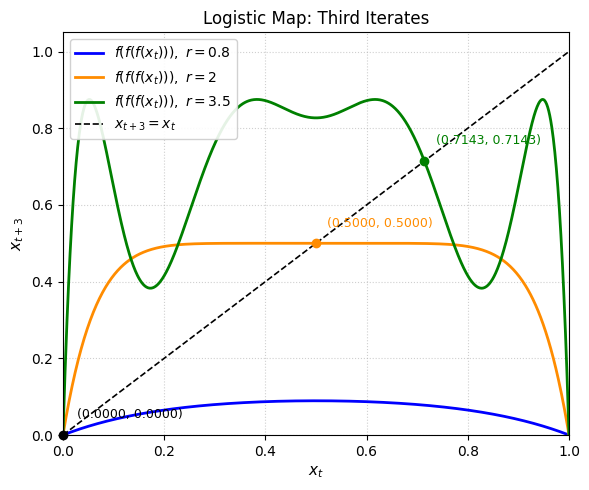

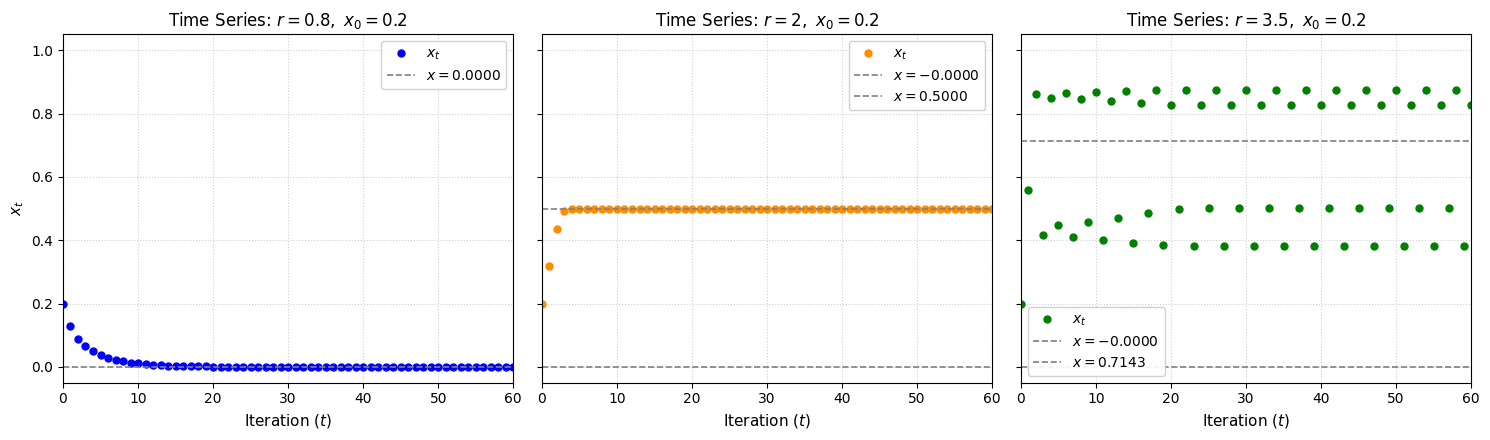

In [11]:
# Imports
from intersect import intersection

# Parameters
r_values = [0.8, 2, 3.5]
colors = ['blue', 'darkorange', 'green']
x0 = 0.2
max_iter = 60

# Map and iteration
def f(x, r):
    return r * x * (1 - x)

def third_iterate(x, r):
    return f(f(f(x, r), r), r)

def iterate(x0, r, max_steps=60):
    orbit = [x0]
    for i in range(max_steps):
        orbit.append(f(orbit[-1], r))
    return orbit

# Intersections
def find_intersections(r):
    x = np.linspace(0, 1, 1000)
    points, y, i, j = intersection(x, third_iterate(x, r), x, x)
    return np.unique(np.clip(points, 0, 1))

# Computational iteration
print('--- Computational Iteration ---')
orbits = {}
intersections = {}
for r in r_values:
    orbit = iterate(x0, r, max_steps=max_iter)
    orbits[r] = orbit
    intersections[r] = find_intersections(r)
    first_few = [f'{val:.4f}' for val in orbit[:6]]
    last_val = f'{orbit[-1]:.5f}'
    intersection_values = [f'{val:.4f}' for val in intersections[r]]
    print(f'r = {r:<4} | x0 = {x0} | Steps: {len(orbit) - 1:<2} | First steps: {first_few} ... | Final value: {last_val}')
    print(f'    Third-iterate intersections: {intersection_values}')

# Third iterates and diagonal
fig_map, ax = plt.subplots(figsize=(6, 5))
x_vals = np.linspace(0, 1, 1000)
for r, color in zip(r_values, colors):
    ax.plot(x_vals, third_iterate(x_vals, r), color=color, linewidth=2, label=f'$f(f(f(x_t))),\\ r = {r}$')
ax.plot(x_vals, x_vals, 'k--', linewidth=1.2, label='$x_{t+3} = x_t$')

# Mark intersections
origin_labeled = False
for r, color in zip(r_values, colors):
    for value in intersections[r]:
        if np.isclose(value, 0, atol=1e-08):
            if origin_labeled:
                continue
            marker_color = 'black'
            offset = (10, 12)
            origin_labeled = True
        else:
            marker_color = color
            offset = (8, 12)
        ax.plot(value, value, 'o', color=marker_color, markersize=6, zorder=5, clip_on=False)
        ax.annotate(f'({value:.4f}, {value:.4f})', xy=(value, value), xytext=offset, textcoords='offset points', fontsize=9, color=marker_color)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_xlabel('$x_t$', fontsize=11)
ax.set_ylabel('$x_{t+3}$', fontsize=11)
ax.set_title('Logistic Map: Third Iterates', fontsize=12)
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.6)
fig_map.tight_layout()

# Time series
fig_ts, axes_ts = plt.subplots(1, len(r_values), figsize=(5 * len(r_values), 4.5), sharey=True)
for ax, r, color in zip(axes_ts, r_values, colors):
    orbit = orbits[r]
    t_vals = list(range(len(orbit)))
    ax.plot(t_vals, orbit, 'o', color=color, markersize=5, label='$x_t$')
    for value in intersections[r]:
        ax.axhline(value, color='gray', linestyle='--', linewidth=1.2, label=f'$x = {value:.4f}$')
    ax.set_xlim(0, max_iter)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('Iteration ($t$)', fontsize=11)
    if ax is axes_ts[0]:
        ax.set_ylabel('$x_t$', fontsize=11)
    ax.legend(loc='best', framealpha=0.9)
    ax.set_title(f'Time Series: $r = {r},\\ x_0 = {x0}$', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
fig_ts.tight_layout()

# Save and display
map_save_path = os.path.join(save_directory, 'Logistic Map Third Iterates.png')
ts_save_path = os.path.join(save_directory, 'Logistic Map Time Series.png')
fig_map.savefig(map_save_path, dpi=300, bbox_inches='tight')
fig_ts.savefig(ts_save_path, dpi=300, bbox_inches='tight')
print(f'\nThird iterate plot saved to: {map_save_path}')
print(f'Time series plot saved to: {ts_save_path}')
plt.show()
